# Fase 0  - Importación de Librerías e Importación de Archivos


In [2]:
pip install datasets

  Using cached datasets-3.5.0-py3-none-any.whl.metadata (19 kB)
  Using cached dill-0.3.8-py3-none-any.whl.metadata (10 kB)
  Using cached requests-2.32.3-py3-none-any.whl.metadata (4.6 kB)
  Using cached tqdm-4.67.1-py3-none-any.whl.metadata (57 kB)
  Using cached fsspec-2024.12.0-py3-none-any.whl.metadata (11 kB)
  Using cached huggingface_hub-0.30.2-py3-none-any.whl.metadata (13 kB)
  Using cached aiohappyeyeballs-2.6.1-py3-none-any.whl.metadata (5.9 kB)
  Using cached aiosignal-1.3.2-py2.py3-none-any.whl.metadata (3.8 kB)
Using cached datasets-3.5.0-py3-none-any.whl (491 kB)
Using cached dill-0.3.8-py3-none-any.whl (116 kB)
Using cached fsspec-2024.12.0-py3-none-any.whl (183 kB)
Using cached huggingface_hub-0.30.2-py3-none-any.whl (481 kB)
   ---------------------------------------- 0.0/12.9 MB ? eta -:--:--
   -------------------------------------- - 12.6/12.9 MB 60.7 MB/s eta 0:00:01
   ---------------------------------------- 12.9/12.9 MB 54.2 MB/s eta 0:00:00
   ---------------

In [3]:
pip install setfit

  Using cached setfit-1.1.2-py3-none-any.whl.metadata (12 kB)
  Using cached sentence_transformers-4.1.0-py3-none-any.whl.metadata (13 kB)
  Using cached transformers-4.51.3-py3-none-any.whl.metadata (38 kB)
  Using cached evaluate-0.4.3-py3-none-any.whl.metadata (9.2 kB)
  Using cached accelerate-1.6.0-py3-none-any.whl.metadata (19 kB)
  Using cached tokenizers-0.21.1-cp39-abi3-win_amd64.whl.metadata (6.9 kB)
  Using cached safetensors-0.5.3-cp38-abi3-win_amd64.whl.metadata (3.9 kB)
  Using cached joblib-1.4.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached networkx-3.4.2-py3-none-any.whl.metadata (6.3 kB)
  Using cached sympy-1.13.1-py3-none-any.whl.metadata (12 kB)
  Using cached mpmath-1.3.0-py3-none-any.whl.metadata (8.6 kB)
Using cached setfit-1.1.2-py3-none-any.whl (75 kB)
Using cached evaluate-0.4.3-py3-none-any.whl (84 kB)
Using cached sentence_transformers-4.1.0-py3-none-any.whl (345 kB)
Using cached transformers-4.51.3-py3-none-any.whl (10.4 MB)
   ------------------------

In [4]:
pip install nltk

  Using cached nltk-3.9.1-py3-none-any.whl.metadata (2.9 kB)
Using cached nltk-3.9.1-py3-none-any.whl (1.5 MB)
Note: you may need to restart the kernel to use updated packages.


In [5]:
pip install torch

Note: you may need to restart the kernel to use updated packages.


In [6]:
pip install transformers

Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd, nltk, numpy as np,torch ,os
from transformers import pipeline
from datasets import Dataset
from setfit import SetFitModel, SetFitTrainer

c:\Users\Administrador\miniconda3\envs\nlp-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Montar Repositorio de Google Drive

Montar el Dataset desde GoogleDrive

In [3]:
# Aquí cambias la ruta para que apunte a la carpeta donde tengas tu archivo
file_path = './googleScholarPeriodAbs.xlsx'

df = pd.read_excel(file_path)



# Fase 1  - Preparación del Dataset

Limpieza de Datos

In [4]:
# Lista de columnas que no conservaremos ya que no aportan al análisis
columns_to_drop = [
    'Column1',
    'IsEnglish',
    'SearchCriteria',
    'period',
    'sumj'
]

# Creamos un nuevo DataFrame sin esas columnas
df_clean = df.drop(columns=columns_to_drop, axis=1)

# Verificamos las columnas resultantes
print(df_clean.columns)



Index(['Title', 'Authors', 'Citations_counts', 'Year', 'Journal', 'Abstract'], dtype='object')


Tratamiento de Datos Nulos

In [5]:
# Ver cuántos valores nulos hay en cada columna
df_clean.isnull().sum()

Title                  0
Authors              625
Citations_counts       0
Year                   0
Journal             2120
Abstract             293
dtype: int64

In [6]:
# 1. Rellenar Journal y Authors con etiqueta genérica
df_clean = df_clean.fillna({
    'Journal': 'NoJournal',
    'Authors': 'NoAuthors'
})

# 2. Eliminar filas que no tengan Abstract (4.3% de datos)
df_clean.dropna(subset=['Abstract'], inplace=True)

# 3. Verificar cuántos nulos quedan
print("Nulos después del tratamiento:\n", df_clean.isnull().sum())

Nulos después del tratamiento:
 Title               0
Authors             0
Citations_counts    0
Year                0
Journal             0
Abstract            0
dtype: int64


Tratamiento de Datos Duplicados

In [7]:
# Verificar si existen datos Duplicados
df_clean.duplicated().sum()

285

In [8]:
import pandas as pd

# 1. Crear un DataFrame sin duplicados
df_no_duplicates = df_clean.drop_duplicates()

# 2. Crear una copia explícita para evitar problemas de vistas
df_no_duplicates = df_no_duplicates.copy()

# 3. Ajustar los tipos de datos
# 3.1. Convertir 'Title' a texto (string)
df_no_duplicates.loc[:, 'Title'] = df_no_duplicates['Title'].astype(str)

# 3.2. Convertir 'Authors' a texto (string)
df_no_duplicates.loc[:, 'Authors'] = df_no_duplicates['Authors'].astype(str)

# 3.3. Convertir 'Citations_counts' a numérico (int, manejando valores no convertibles)
df_no_duplicates.loc[:, 'Citations_counts'] = pd.to_numeric(df_no_duplicates['Citations_counts'], errors='coerce').fillna(0).astype(int)

# 3.4. Convertir 'Year' a numérico (int, manejando errores de conversión)
df_no_duplicates.loc[:, 'Year'] = pd.to_numeric(df_no_duplicates['Year'], errors='coerce').fillna(0).astype(int)

# 3.5. Convertir 'Journal' a texto (string)
df_no_duplicates.loc[:, 'Journal'] = df_no_duplicates['Journal'].astype(str)

# 3.6. Convertir 'Abstract' a texto (string)
df_no_duplicates.loc[:, 'Abstract'] = df_no_duplicates['Abstract'].astype(str)

# 4. Ver cuántas filas quedaron después de eliminar duplicados
print("Filas antes:", df_clean.shape[0])
print("Filas después:", df_no_duplicates.shape[0])

# 5. Guardar en un CSV
output_path = "./abstracs_cleaned.csv"
df_no_duplicates.to_csv(output_path, index=False)

print(f"✅ Proceso finalizado. Archivo guardado en: {output_path}")

Filas antes: 6476
Filas después: 6191
✅ Proceso finalizado. Archivo guardado en: ./abstracs_cleaned.csv


# Fase 2  - Clasificación por Corriente Filosófica

In [7]:
%pip install -U "torch>=2.1" \
               "transformers[torch]>=4.39" \
               "datasets>=2.18" \
               "accelerate>=0.26" \
               "setfit>=1.3" \
               nltk -q

Note: you may need to restart the kernel to use updated packages.


ERROR: Could not find a version that satisfies the requirement setfit>=1.3 (from versions: 0.0.1, 0.0.2, 0.1.0, 0.1.1, 0.2.0, 0.3.0, 0.4.0, 0.4.1, 0.5.0, 0.6.0, 0.7.0, 1.0.0, 1.0.1, 1.0.2, 1.0.3, 1.1.0, 1.1.1, 1.1.2)
ERROR: No matching distribution found for setfit>=1.3


In [8]:
# ================================================================
# 0. Librerías e instalación (una sola vez)
# ================================================================
%pip install -U transformers datasets setfit nltk accelerate -q

Note: you may need to restart the kernel to use updated packages.


In [9]:
pip install 'accelerate>=0.26.0

Note: you may need to restart the kernel to use updated packages.


ERROR: Invalid requirement: "'accelerate": Expected package name at the start of dependency specifier
    'accelerate
    ^


In [2]:
import nltk, os

# Ruta donde NLTK guardará sus corpora; cámbiala si prefieres otra
nltk_data_dir = os.path.expanduser("~/nltk_data")
os.makedirs(nltk_data_dir, exist_ok=True)

# Indica a NLTK dónde buscar
nltk.data.path.append(nltk_data_dir)

# Descarga modelos necesarios
for pkg in ["punkt", "punkt_tab"]:
    try:
        nltk.data.find(f"tokenizers/{pkg}")
    except LookupError:
        nltk.download(pkg, download_dir=nltk_data_dir)


[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\Administrador/nltk_data...
[nltk_data]   Unzipping tokenizers\punkt_tab.zip.


In [6]:
import os, random, numpy as np, pandas as pd, torch, nltk
from datasets import Dataset
from transformers import pipeline
from transformers.pipelines.pt_utils import KeyDataset
from setfit import SetFitModel, Trainer, TrainingArguments

# ------------------------------------------------------------------
# 0. Recursos NLTK (asegura "punkt")
# ------------------------------------------------------------------
nltk_data_dir = os.path.expanduser("~/nltk_data")
os.makedirs(nltk_data_dir, exist_ok=True)
nltk.data.path.append(nltk_data_dir)
try:
    nltk.data.find("tokenizers/punkt")
except LookupError:
    nltk.download("punkt", download_dir=nltk_data_dir)

# ------------------------------------------------------------------
# 1. Constantes y configuraciones
# ------------------------------------------------------------------
LABELS = ["Realism", "Constructivism", "Relativism", "Pragmatism"]
VERBALIZERS = {lab: f"({lab})" for lab in LABELS}          # verbalizador mínimo
TEMPLATE    = "This abstract adopts a {} stance"

BATCH_ZS = 32         # lote para zero‑shot
BATCH_DS = 128        # lote en datasets.map
ALPHA    = 0.5        # 50 % SetFit + 50 % zero‑shot  (ajústalo si lo deseas)

DEVICE = 0 if torch.cuda.is_available() else -1

# ------------------------------------------------------------------
# 2. Carga de datos
# ------------------------------------------------------------------
df_raw  = pd.read_csv("./abstracs_cleaned.csv")
df_seed = pd.read_csv("./seed_generated.csv").astype({"label": int})

# ------------------------------------------------------------------
# 3. Fine‑tuning SetFit
# ------------------------------------------------------------------
model = SetFitModel.from_pretrained(
    "sentence-transformers/paraphrase-mpnet-base-v2",
    device="cuda" if DEVICE == 0 else "cpu",
)

train_ds = Dataset.from_pandas(df_seed[["text", "label"]])

trainer = Trainer(
    model=model,
    args=TrainingArguments(
        num_iterations=400,    # 400 × 4 × 2 = 3 200 pares contrastivos
        batch_size=16,
        seed=42,
    ),
    train_dataset=train_ds,
)
trainer.train()

def setfit_predict_all(texts, batch=128):
    """Matriz de probabilidades SetFit (n × 4)."""
    return trainer.model.predict_proba(texts, batch_size=batch)

# ------------------------------------------------------------------
# 4. Zero‑shot batched
# ------------------------------------------------------------------
zs_classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=DEVICE,
    batch_size=BATCH_ZS,
    truncation_strategy="only_first",
)

def zs_predict_all(texts):
    """Matriz de probabilidades zero‑shot (n × 4)."""
    #  preparamos una lista de dicts para KeyDataset
    ds = [{"text": t} for t in texts]

    outs = zs_classifier(
        KeyDataset(ds, "text"),                 #  ✓ ahora sí funciona
        candidate_labels=list(VERBALIZERS.values()),
        hypothesis_template=TEMPLATE,
        batch_size=BATCH_ZS,
    )

    scores = np.zeros((len(texts), len(LABELS)))
    for i, out in enumerate(outs):
        for j, lab in enumerate(LABELS):
            scores[i, j] = out["scores"][out["labels"].index(VERBALIZERS[lab])]
    return scores

# ------------------------------------------------------------------
# 5. Voting + fusión en lote
# ------------------------------------------------------------------
def safe_split(txt):
    segs = nltk.sent_tokenize(txt.strip())
    return segs if segs else [txt]

def predict_batch_voting(batch_texts):
    seg_batches = [safe_split(t) for t in batch_texts]
    flat_segs   = sum(seg_batches, [])

    sf_flat = setfit_predict_all(flat_segs, batch=128)
    zs_flat = zs_predict_all(flat_segs)

    idx, labels_out, conf_out = 0, [], []
    for segs in seg_batches:
        n = len(segs)

        # ---- medias forzadas a ndarray(float)  ----
        sf_mean = np.asarray(sf_flat[idx:idx+n].mean(axis=0), dtype=float)
        zs_mean = np.asarray(zs_flat[idx:idx+n].mean(axis=0), dtype=float)
        idx    += n

        mix  = (1 - ALPHA) * zs_mean + ALPHA * sf_mean    
        best = mix.argmax()
        labels_out.append(LABELS[best])
        conf_out.append(float(mix[best]))
    return labels_out, conf_out



# ------------------------------------------------------------------
# 6. Procesamiento del dataset completo
# ------------------------------------------------------------------
def map_fn(batch):
    labs, confs = predict_batch_voting(batch["Abstract"])
    batch["Predicted_Label"] = labs
    batch["Confidence"]      = confs
    return batch

dataset = Dataset.from_pandas(df_raw)
dataset = dataset.map(map_fn, batched=True, batch_size=BATCH_DS)

out = dataset.to_pandas()
out.to_csv("classified_articles_setfit.csv", index=False)
print("Confianza media:", out["Confidence"].mean().round(4))


model_head.pkl not found on HuggingFace Hub, initialising classification head with random weights. You should TRAIN this model on a downstream task to use it for predictions and inference.
Map: 100%|██████████| 500/500 [00:00<00:00, 6435.03 examples/s]
***** Running training *****
  Num unique pairs = 400000
  Batch size = 16
  Num epochs = 1


Step,Training Loss
1,0.286700
50,0.225500
100,0.203200
150,0.138300
200,0.066300
250,0.021900
300,0.007700
350,0.004300
400,0.002900
450,0.002000


Device set to use cuda:0
Map: 100%|██████████| 6191/6191 [5:28:43<00:00,  3.19s/ examples]  

Confianza media: 0.4846


In [1]:
import torch, sys, subprocess, platform
print("PyTorch :", torch.__version__)
print("Compilado con CUDA :", torch.version.cuda)
print("Python  :", sys.executable)
print("SO      :", platform.platform())

PyTorch : 2.5.1+cu121
Compilado con CUDA : 12.1
Python  : c:\Users\Administrador\miniconda3\envs\nlp-gpu\python.exe
SO      : Windows-10-10.0.19045-SP0


In [4]:
!pip uninstall -y torch torchvision torchaudio

Found existing installation: torch 2.6.0
Uninstalling torch-2.6.0:
  Successfully uninstalled torch-2.6.0


You can safely remove it manually.


In [5]:
!pip install --upgrade pip


   ---------------------------------------- 0.0/1.8 MB ? eta -:--:--
   ---------------------------------------- 1.8/1.8 MB 33.6 MB/s eta 0:00:00


ERROR: To modify pip, please run the following command:
C:\Users\Administrador\miniconda3\envs\nlp-gpu\python.exe -m pip install --upgrade pip


In [6]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Looking in indexes: https://download.pytorch.org/whl/cu121
     ---------------------------------------- 0.0/2.4 GB ? eta -:--:--
     ---------------------------------------- 0.0/2.4 GB 62.5 MB/s eta 0:00:40
      --------------------------------------- 0.0/2.4 GB 88.8 MB/s eta 0:00:28
      --------------------------------------- 0.1/2.4 GB 101.1 MB/s eta 0:00:24
     - -------------------------------------- 0.1/2.4 GB 104.7 MB/s eta 0:00:23
     - -------------------------------------- 0.1/2.4 GB 100.4 MB/s eta 0:00:24
     - -------------------------------------- 0.1/2.4 GB 98.7 MB/s eta 0:00:24
     -- ------------------------------------- 0.1/2.4 GB 94.6 MB/s eta 0:00:25
     -- ------------------------------------- 0.1/2.4 GB 91.3 MB/s eta 0:00:26
     -- ------------------------------------- 0.2/2.4 GB 88.7 MB/s eta 0:00:26
     -- ------------------------------------- 0.2/2.4 GB 87.3 MB/s eta 0:00:26
     --- ------------------------------------ 0.2/2.4 GB 86.0 MB/s eta 0:00:2

In [9]:
csv_path = "./classified_articles_setfit.csv"   # ajusta si lo guardaste en otra carpeta
df = pd.read_csv(csv_path)

# Promedio de la confianza
mean_conf = df["Confidence"].mean()
print(f"Confianza media: {mean_conf:.4f}")

# Desviación estándar y percentiles para tener idea de la dispersión
std_conf  = df["Confidence"].std()
p25, p50, p75 = df["Confidence"].quantile([0.25, 0.5, 0.75])
print(f"Std: {std_conf:.4f} | P25: {p25:.3f} | Mediana: {p50:.3f} | P75: {p75:.3f}")


Confianza media: 0.4846
Std: 0.1060 | P25: 0.398 | Mediana: 0.472 | P75: 0.584


In [10]:
out.groupby("Predicted_Label")["Confidence"].describe()

,count,mean,std,min,25%,50%,75%,max
Predicted_Label,,,,,,,,
Constructivism,4608.0,0.502207,0.099538,0.260446,0.423969,0.498404,0.592498,0.968165
Pragmatism,910.0,0.450709,0.112089,0.271189,0.373592,0.418390,0.492518,0.893940
Realism,163.0,0.382649,0.088167,0.266643,0.330312,0.366141,0.393926,0.736061
Relativism,510.0,0.419146,0.097200,0.256545,0.354226,0.389722,0.457098,0.763206


In [11]:
# Recargar el CSV de salida del modelo clasificador
out = pd.read_csv("./classified_articles_setfit.csv")

# Agrupar y contar las predicciones con confianza >= 0.6 por clase
high_conf_counts = out[out["Confidence"] >= 0.6].groupby("Predicted_Label").size()
high_conf_counts = high_conf_counts.sort_values(ascending=False)
high_conf_counts

Predicted_Label
Constructivism    978
Pragmatism        132
Relativism         50
Realism             9
dtype: int64

In [13]:
pip install seaborn

  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
  Using cached cycler-0.12.1-py3-none-any.whl.metadata (3.8 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)
   ---------------------------------------- 0.0/8.1 MB ? eta -:--:--
   ---------------------------------------  7.9/8.1 MB 60.8 MB/s eta 0:00:01
   ---------------------------------------- 8.1/8.1 MB 29.3 MB/s eta 0:00:00
Using cached cycler-0.12.1-py3-none-any.whl (8.3 kB)
   ---------------------------------------- 0.0/2.2 MB ? eta -:--:--
   ---------------------------------------- 2.2/2.2 MB 62.7 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [14]:
pip install matplotlib

Note: you may need to restart the kernel to use updated packages.


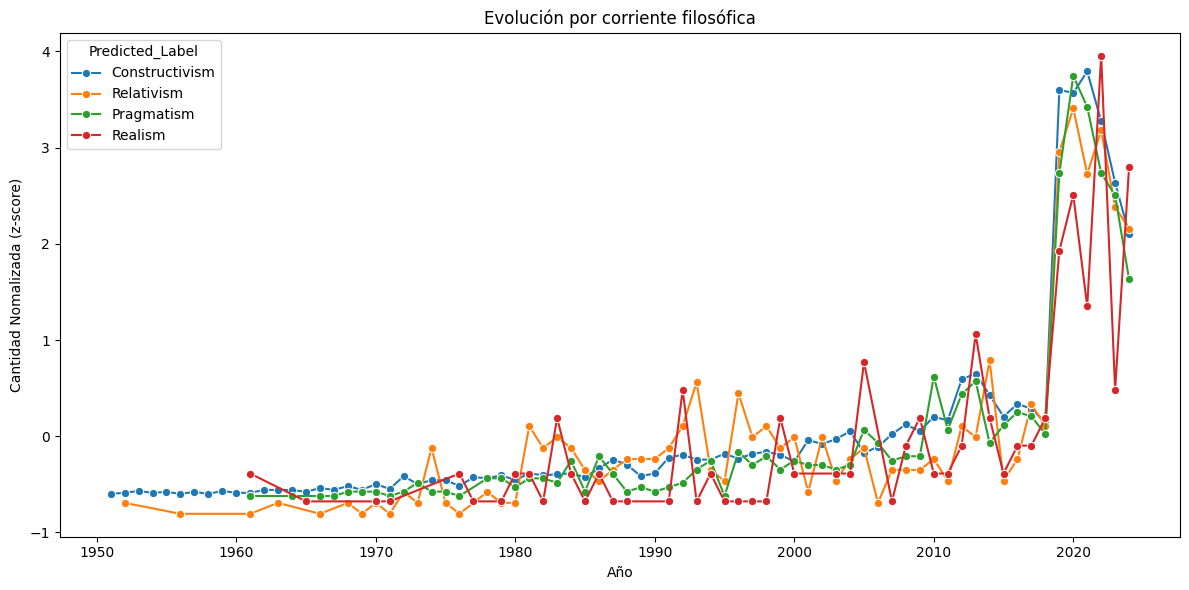

In [8]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import zscore

# ----------------------------------------
# 1. Cargar datos clasificados
# ----------------------------------------
df = pd.read_csv("classified_articles_setfit.csv")
df = df[df["Year"].between(1950, 2025)]

# ----------------------------------------
# 2. Cantidad absoluta por año y clase
# ----------------------------------------
count_by_year = (
    df.groupby(["Year", "Predicted_Label"])
    .size()
    .reset_index(name="Cantidad")
)


# ----------------------------------------
# 2. Gráfica por año y clase
# ----------------------------------------
count_by_year["Cantidad_z"] = (
    count_by_year.groupby("Predicted_Label")["Cantidad"]
    .transform(zscore)
)

plt.figure(figsize=(12, 6))
sns.lineplot(
    data=count_by_year,
    x="Year", y="Cantidad_z", hue="Predicted_Label", marker="o"
)
plt.title("Evolución por corriente filosófica")
plt.ylabel("Cantidad Nomalizada (z-score)")
plt.xlabel("Año")
plt.tight_layout()
plt.show()


El gráfico presentado muestra la evolución temporal del número de artículos científicos clasificados en cuatro corrientes filosóficas —Constructivism, Relativism, Pragmatism y Realism— entre 1950 y 2025, observando el comportamiento relativo de cada corriente respecto a su propia media histórica.

Se observa que todas las corrientes experimentan un incremento sustancial en su valor z-score a partir del año 2020. Este fenómeno sugiere un cambio importante en el comportamiento de las publicaciones científicas relacionadas con enfoques filosóficos, destacando especialmente el caso de Constructivism,

Relativism, Pragmatism y Realism también muestran aumentos notables en este mismo periodo, alcanzando valores que reflejan un crecimiento destacado en comparación con sus propias trayectorias previas. Este patrón común podría estar asociado a transformaciones recientes en las agendas de investigación, posiblemente relacionadas con fenómenos globales recientes como la digitalización acelerada, la transformación de paradigmas científicos o el impacto social y epistemológico de eventos disruptivos a nivel mundial, así también atribuibles a un aumento general de publicaciones no solo dentro de la rama de la filosfía si no de la ciencia durante la pandema de de COVID-19.

Podemos evidenciar no sólo los patrones históricos de cada corriente, sino también un punto de inflexión reciente que justifica un análisis más profundo sobre los factores que podrían estar motivando este resurgimiento o reconfiguración de enfoques filosóficos en la investigación académica contemporánea, además de los ya mencionados

# Fase 3 - Clasificación por sub-temática

In [9]:
pip install bertopic hdbscan umap-learn sentence-transformers

   ---------------------------------------- 0.0/732.2 kB ? eta -:--:--
   --------------------------------------- 732.2/732.2 kB 14.7 MB/s eta 0:00:00
   ---------------------------------------- 0.0/2.8 MB ? eta -:--:--
   ---------------------------------------- 2.8/2.8 MB 41.4 MB/s eta 0:00:00
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 14.8/14.8 MB 93.2 MB/s eta 0:00:00
   ---------------------------------------- 0.0/30.3 MB ? eta -:--:--
   ----------------------- ---------------- 17.6/30.3 MB 79.0 MB/s eta 0:00:01
   ---------------------------------------- 30.3/30.3 MB 71.3 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [7]:
import pandas as pd
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer
import torch

# -----------------------------
# 1. Preparar embeddings en GPU
# -----------------------------
device = "cuda" if torch.cuda.is_available() else "cpu"
embedding_model = SentenceTransformer("paraphrase-mpnet-base-v2", device=device)

# -----------------------------
# 2. Cargar todo el dataset
# -----------------------------
df = pd.read_csv("classified_articles_setfit.csv")
docs = df["Abstract"].dropna().tolist()

# -----------------------------
# 3. Entrenar BERTopic global
# -----------------------------
topic_model = BERTopic(embedding_model=embedding_model, language="english", hdbscan_model=None)
topics, probs = topic_model.fit_transform(docs)

# -----------------------------
# 4. Guardar visualizaciones interactivas
# -----------------------------
fig_topics = topic_model.visualize_topics()
fig_bar = topic_model.visualize_barchart(top_n_topics=15)

fig_topics.write_html("temas_interactivos.html")
fig_bar.write_html("top_15_temas_bar.html")

print("✅ Visualizaciones guardadas como:")
print("   → temas_interactivos.html (diagrama interactivo de temas)")
print("   → top_15_temas_bar.html (gráfico de barras con los temas más frecuentes)")


✅ Visualizaciones guardadas como:
   → temas_interactivos.html (diagrama interactivo de temas)
   → top_15_temas_bar.html (gráfico de barras con los temas más frecuentes)


In [8]:
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity
from collections import Counter

# Paso 1: Obtener embeddings de todos los documentos
embeddings = embedding_model.encode(docs, show_progress_bar=True)
top_topic_ids = [tid for tid, _ in Counter(topics).most_common(15)]

# Paso 2: Calcular el centroide de cada uno de esos los
topic_centroids = {
    tid: np.mean([embeddings[i] for i, t in enumerate(topics) if t == tid], axis=0)
    for tid in top_topic_ids
}

# Paso 4: Función para encontrar el topic más cercano entre los temas
def find_closest_topic(embedding):
    similarities = {tid: cosine_similarity([embedding], [centroid])[0][0]
                    for tid, centroid in topic_centroids.items()}
    return max(similarities, key=similarities.get)

# Paso 5: Aplicar la reclasificación 
forced_topic_ids = [find_closest_topic(e) for e in embeddings]
df["Automatic_Topic_ID"] = forced_topic_ids

# Paso 6: Asignar etiquetas automáticas 
topic_labels = {
    tid: ", ".join([word for word, _ in topic_model.get_topic(tid)[:5]])
    for tid in top_topic_ids
}
df["Automatic_Topic_Label"] = df["Automatic_Topic_ID"].map(topic_labels)

# Paso 7: Exportar resultado
df.to_csv("abstracts_reclasificados_top15.csv", index=False)
print("Todos los abstracts fueron clasificados entre los 15 temas más comunes.")
print("Archivo generado: abstracts_reclasificados_top15.csv")


Batches: 100%|██████████| 194/194 [02:54<00:00,  1.11it/s]


Todos los abstracts fueron clasificados entre los 15 temas más comunes.
Archivo generado: abstracts_reclasificados_top15.csv


In [9]:
from collections import Counter

top_topic_ids = [tid for tid, _ in Counter(forced_topic_ids).most_common(15)]

# Mostrar palabras clave de cada uno
for tid in top_topic_ids:
    topic_words = topic_model.get_topic(tid)
    if topic_words:
        top_words = ", ".join([w for w, _ in topic_words[:10]])
        print(f"🟢 Topic {tid}: {top_words}")
    else:
        print(f"⚪️ Topic {tid}: <sin palabras clave>")


🟢 Topic -1: the, of, and, to, in, is, that, as, science, this
🟢 Topic 0: sociology, knowledge, mannheim, of, the, his, is, social, in, to
🟢 Topic 10: philosophy, science, philosophical, scientific, of, the, practice, that, and, is
🟢 Topic 8: technology, social, science, studies, and, of, technoscience, the, technological, in
🟢 Topic 4: anthropology, anthropological, anthropologists, culture, ethnography, cultural, the, of, to, and
🟢 Topic 12: history, science, historiography, the, of, in, tomsk, astronomy, this, and
🟢 Topic 1: education, curriculum, knowledge, educational, bernstein, school, in, the, and, of
🟢 Topic 3: science, education, students, teachers, teaching, nature, learning, in, teacher, and
🟢 Topic 5: medical, health, patients, medicine, clinical, patient, and, in, illness, of
🟢 Topic 6: ai, intelligence, artificial, robots, systems, human, machine, robot, to, and
🟢 Topic 2: women, gender, feminist, and, in, technology, of, the, to, this
🟢 Topic 13: economic, economics, mar

In [ ]:
# Diccionario de etiquetas filosóficas
topic_labels = {
    -1:  "Outlier",  
     0:  "Sociología del conocimiento",
    10:  "Filosofía de la ciencia",
     8:  "Filosofía de la tecnología",
     4:  "Antropología de la ciencia",
    12:  "Historia de la ciencia",
     1:  "Filosofía de la educación",
     3:  "Pedagogía de la ciencia",
     5:  "Filosofía de la medicina",
     6:  "Filosofía de la inteligencia artificial",
     2:  "Epistemología feminista",
    13:  "Filosofía económica",
    11:  "Filosofía de la salud pública",
     7:  "Estudios Ciencia-Tecnología-Sociedad (CTS)",
     9:  "Naturaleza de la Ciencia (NOS)"
}

# Luego, asigna las etiquetas al DataFrame
# Supongamos que tu columna forzada se llama "Forced_Topic_ID"
df["Topic_Label"] = df["Automatic_Topic_ID"].map(topic_labels)

# Y por si acaso compruebas que no quede ningún NaN:
assert df["Topic_Label"].isna().sum() == 0

# Finalmente, exporta o contabiliza:
df.to_csv("abstracts_clasificados_filosóficos.csv", index=False)
print(df["Topic_Label"].value_counts().sort_values(ascending=False))


Topic_Label
Outlier                                       1617
Sociología del conocimiento                    980
Filosofía de la ciencia                        537
Filosofía de la tecnología                     523
Antropología de la ciencia                     408
Historia de la ciencia                         331
Filosofía de la educación                      312
Pedagogía de la ciencia                        280
Filosofía de la medicina                       274
Filosofía de la inteligencia artificial        203
Epistemología feminista                        193
Filosofía económica                            167
Filosofía de la salud pública                  150
Estudios Ciencia-Tecnología-Sociedad (CTS)     141
Naturaleza de la Ciencia (NOS)                  75
Name: count, dtype: int64


# Fase 4 - Clasificación por tipo de investigación (Cualitativo y Cuantitativo)

In [19]:
pip install transformers torch


Note: you may need to restart the kernel to use updated packages.


In [5]:
import pandas as pd
import torch
from transformers import pipeline
from datasets import Dataset, DatasetDict

# 1. Carga tu CSV
df = pd.read_csv("abstracts_clasificados_filosóficos.csv")

# 2. Prepara el pipeline
classifier = pipeline(
    "zero-shot-classification",
    model="facebook/bart-large-mnli",
    device=0 if torch.cuda.is_available() else -1
)

candidate_labels = [
    "Quantitative research (involves numerical data, statistical analysis, surveys, experiments)",
    "Qualitative research (involves interviews, focus groups, thematic or content analysis, participant observation)"
]
hypothesis_template = "This abstract describes a {} study."

# 3. Crea un Hugging Face Dataset
ds = Dataset.from_pandas(df[["Abstract"]])

# 4. Función de clasificación *batched*
def classify_batch(batch):
    texts = batch["Abstract"]
    # pipeline admite listas directamente y respeta device+batch_size
    out = classifier(
        texts,
        candidate_labels=candidate_labels,
        hypothesis_template=hypothesis_template,
        multi_label=False,
        batch_size=32
    )
    # extraemos los dos campos que queremos
    return {
        "Methodology": [o["labels"][0] for o in out],
        "Confidence":  [o["scores"][0] for o in out]
    }

# 5. Ejecuta .map() en *batch* para todo el dataset
ds = ds.map(
    classify_batch,
    batched=True,
    batch_size=32,      # ajusta según tu GPU
    remove_columns=["Abstract"]
)

# 6. Combina resultados con tu DataFrame original
df[["Methodology", "Confidence"]] = ds.to_pandas()[["Methodology", "Confidence"]]

# 7. Guarda y revisa conteo
df.to_csv("abstracts_con_metodologia_optimizado.csv", index=False)
print(df["Methodology"].value_counts())


Device set to use cuda:0
Map: 100%|██████████| 6191/6191 [2:01:54<00:00,  1.18s/ examples]  


Methodology
Qualitative research (involves interviews, focus groups, thematic or content analysis, participant observation)    3783
Quantitative research (involves numerical data, statistical analysis, surveys, experiments)                        2408
Name: count, dtype: int64


# Fase 5 - Identificación de Autores

In [3]:
pip install huggingface_hub[hf_xet]

   ---------------------------------------- 0.0/4.1 MB ? eta -:--:--
   ---------------------------------------- 4.1/4.1 MB 41.5 MB/s eta 0:00:00
Note: you may need to restart the kernel to use updated packages.


In [1]:
import pandas as pd
import torch
from transformers import pipeline
from datasets import Dataset

# 1. Carga tu CSV con abstracts
df = pd.read_csv("abstracts_con_metodologia_optimizado.csv")

# 2. Prepara el pipeline de NER en GPU
ner_pipeline = pipeline(
    "ner",
    model="dbmdz/bert-large-cased-finetuned-conll03-english",
    aggregation_strategy="simple",  # agrupa tokens contiguos
    device=0 if torch.cuda.is_available() else -1
)

# 3. Crea un Hugging Face Dataset solo con la columna Abstract
ds = Dataset.from_pandas(df[["Abstract"]])

# 4. Función para extraer nombres propios de persona
def extract_authors(batch):
    texts = batch["Abstract"]
    entities = ner_pipeline(texts, batch_size=32)
    
    authors = []
    for ent_list in entities:
        # Filtra solo entidades de tipo PER (persona)
        names = [e["word"] for e in ent_list if e.get("entity_group", "").upper() in ("PER", "PERSON")]
        if names:
            # Conserva únicos respetando orden
            unique_names = list(dict.fromkeys(names))
            authors.append(", ".join(unique_names))
        else:
            authors.append("No author found")
    return {"Authors": authors}

# 5. Aplica la extracción en batch
ds = ds.map(
    extract_authors,
    batched=True,
    batch_size=32,
    remove_columns=["Abstract"]
)

# 6. Añade resultado al DataFrame original
df["Authors"] = ds["Authors"]

# 7. Guarda CSV con la nueva columna
df.to_csv("abstracts_with_authors.csv", index=False)

# 8. Muestra los primeros resultados
df[["Abstract", "Authors"]].head(10)


c:\Users\Administrador\miniconda3\envs\nlp-gpu\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
Some weights of the model checkpoint at dbmdz/bert-large-cased-finetuned-conll03-english were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).
Device set to use cuda:0
Map: 100%|████

,Abstract,Authors
0,This chapter reviews the literature in the soc...,F. Bacon
1,Contemporary science is marked by expanding an...,No author found
2,This paper looks at science communication thro...,No author found
3,"In late February 2019, when the Covid-19 crisi...","Wonyong Park, Newton, Olivia Levrini"
4,We are weak today in ideal matters because int...,No author found
5,Although science studies routinely assume that...,"Gläser, Laudel, Evans, Krimsky"
6,Although use of the term synthetic biology in ...,"Drew Endy, Campos"
7,"In the wake of the global financial crisis, th...",No author found
8,"In this position paper, I examine how the hist...",No author found
9,Traveling to conferences is a central feature ...,No author found


# Fase 6 - Visualizaciones de la gráfica

## Distribución de abstracts por tema

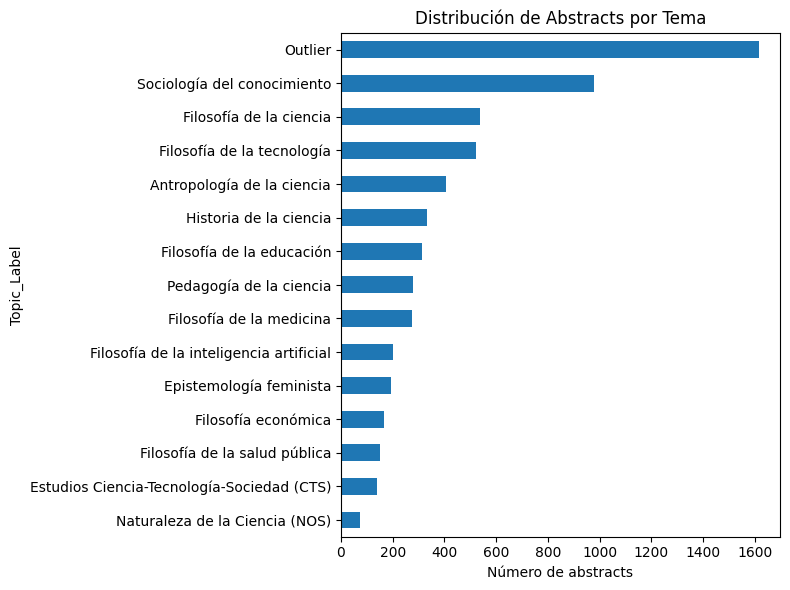

In [2]:
import matplotlib.pyplot as plt
counts = df["Topic_Label"].value_counts().sort_values(ascending=True)
plt.figure(figsize=(8,6))
counts.plot.barh()
plt.title("Distribución de Abstracts por Tema")
plt.xlabel("Número de abstracts")
plt.tight_layout()
plt.show()


##  Metodología: cuantitativo vs cualitativo

C:\Users\Administrador\AppData\Local\Temp\ipykernel_15524\2293562949.py:5: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


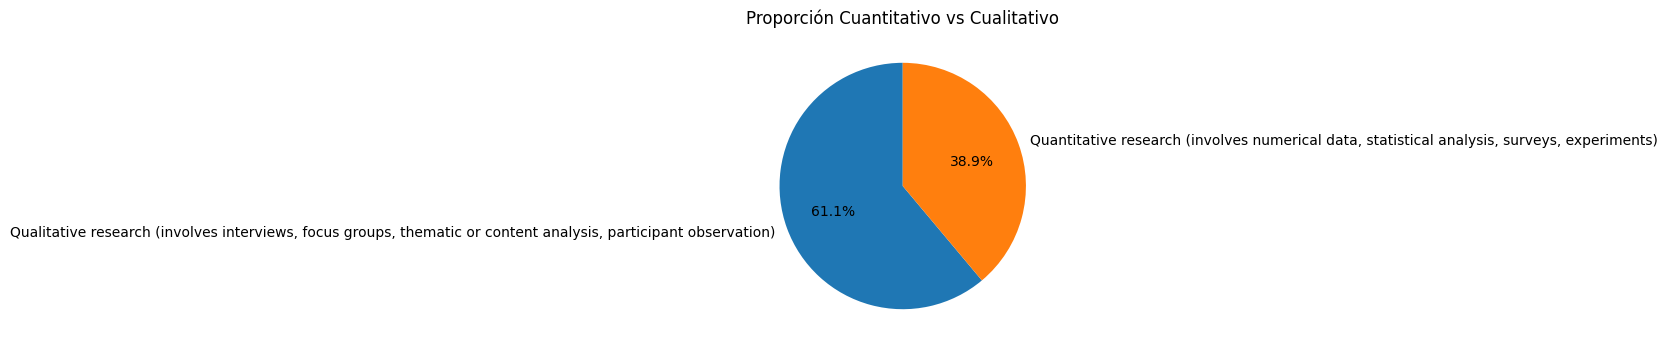

In [3]:
plt.figure(figsize=(4,4))
df["Methodology"].value_counts().plot.pie(autopct="%1.1f%%", startangle=90)
plt.ylabel("")
plt.title("Proporción Cuantitativo vs Cualitativo")
plt.tight_layout()
plt.show()


## Relación Tema ↔ Metodología

C:\Users\Administrador\AppData\Local\Temp\ipykernel_15524\2716122930.py:8: UserWarning: Tight layout not applied. The bottom and top margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


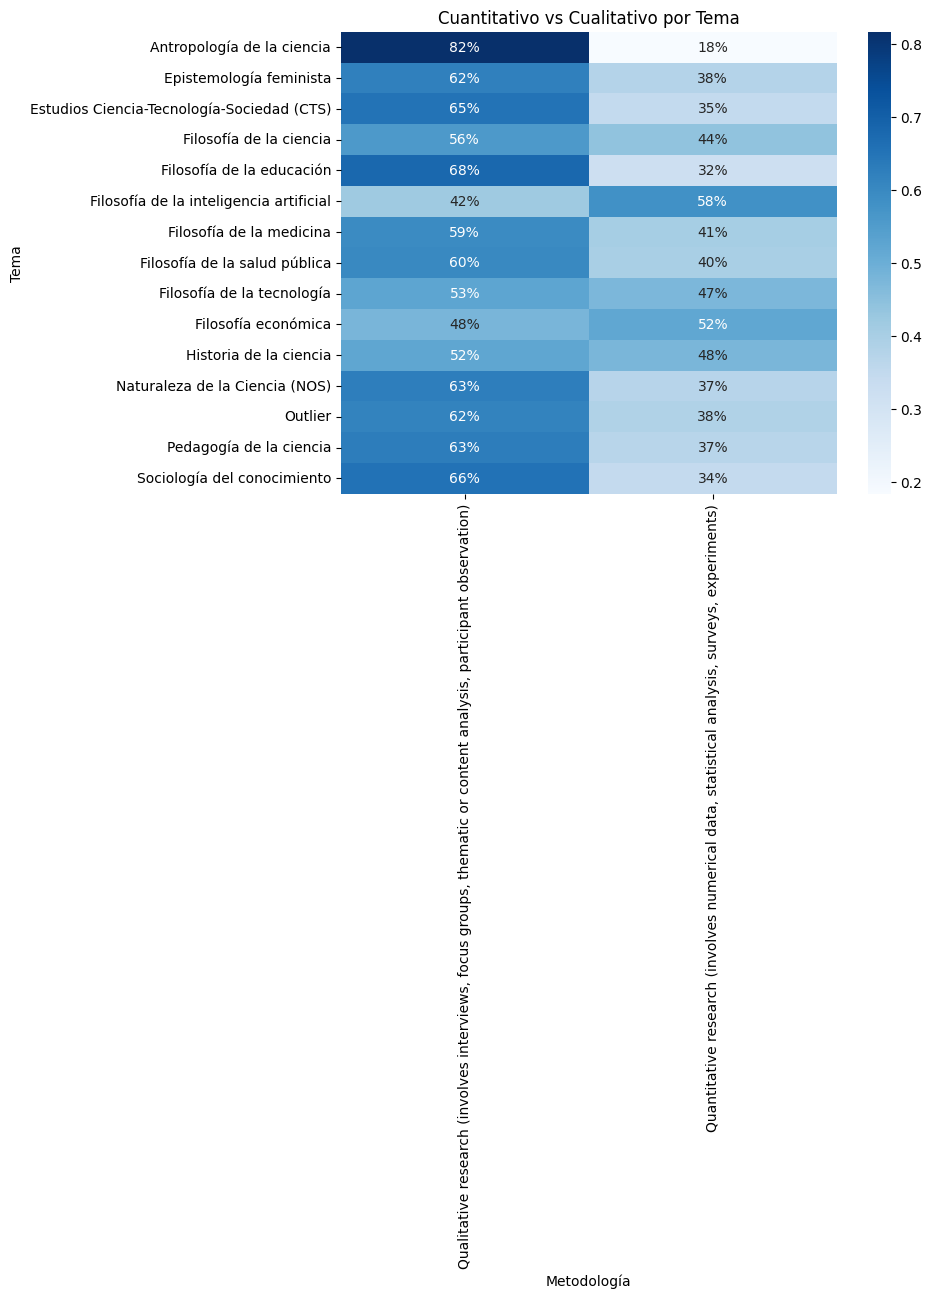

In [4]:
import seaborn as sns
cross = pd.crosstab(df["Topic_Label"], df["Methodology"], normalize="index")
plt.figure(figsize=(8,6))
sns.heatmap(cross, annot=True, fmt=".0%", cmap="Blues")
plt.title("Cuantitativo vs Cualitativo por Tema")
plt.xlabel("Metodología")
plt.ylabel("Tema")
plt.tight_layout()
plt.show()


## Top autores extraídos

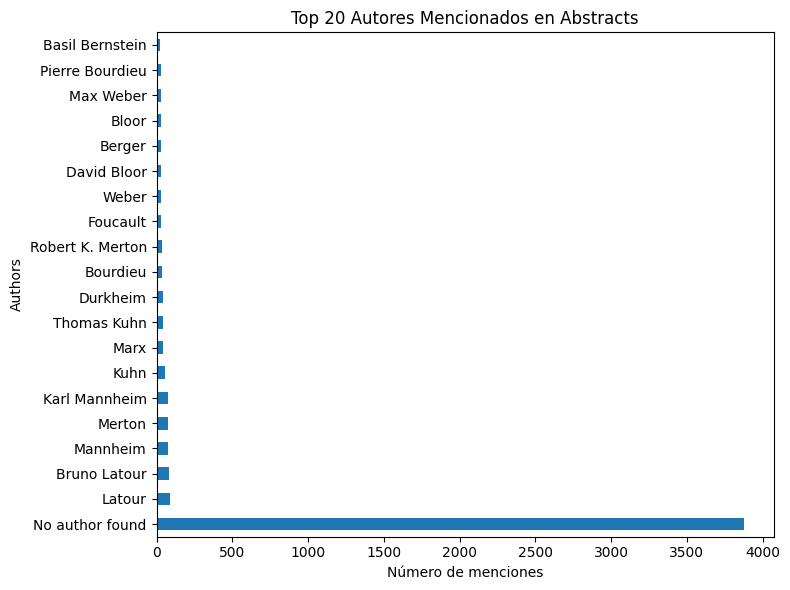

In [5]:
top_authors = df["Authors"].str.split(", ").explode().value_counts().head(20)
plt.figure(figsize=(8,6))
top_authors.plot.barh()
plt.title("Top 20 Autores Mencionados en Abstracts")
plt.xlabel("Número de menciones")
plt.tight_layout()
plt.show()


## Tendencia temporal de los temas

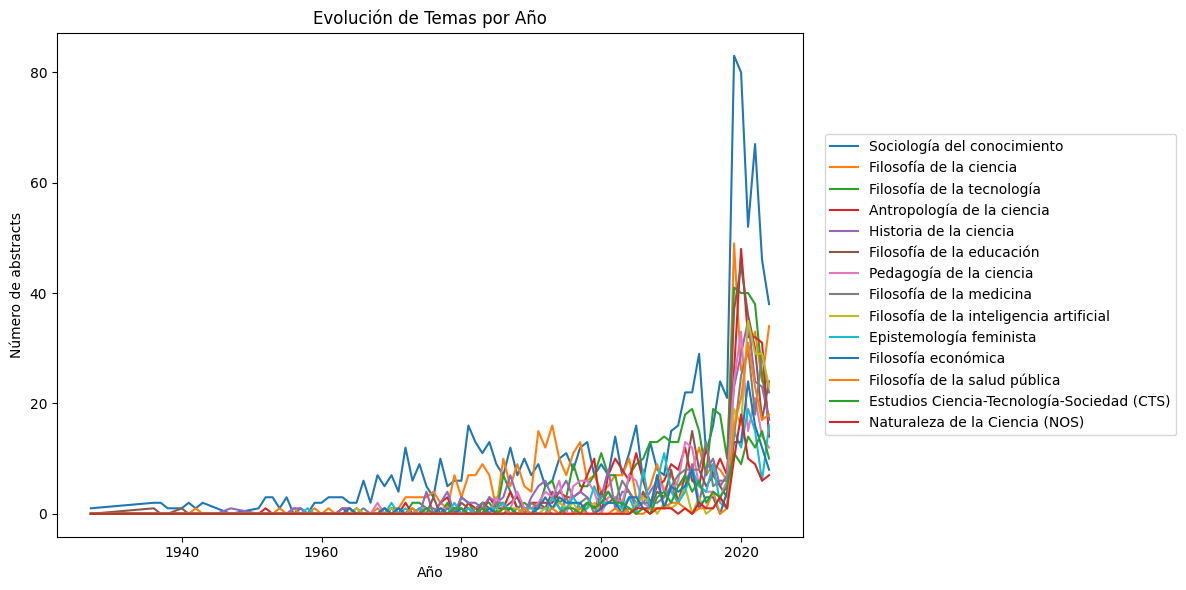

In [13]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Carga tu CSV
df = pd.read_csv("abstracts_con_metodologia_optimizado.csv")

# 2. Asegúrate de que 'year' es numérico
df["Year"] = pd.to_numeric(df["Year"], errors="coerce")
df = df[df["Year"].between(1927, 2024)]

# 3. Crea la tabla cruzada año ↔ tema
pivot = pd.crosstab(df["Year"], df["Topic_Label"])

# 4. Elige el orden de tus 15 etiquetas (mismo que usaste en el diccionario)
top_labels = [
        "Sociología del conocimiento",
    "Filosofía de la ciencia",
    "Filosofía de la tecnología",
    "Antropología de la ciencia",
    "Historia de la ciencia",
    "Filosofía de la educación",
    "Pedagogía de la ciencia",
    "Filosofía de la medicina",
    "Filosofía de la inteligencia artificial",
    "Epistemología feminista",
    "Filosofía económica",
    "Filosofía de la salud pública",
    "Estudios Ciencia-Tecnología-Sociedad (CTS)",
    "Naturaleza de la Ciencia (NOS)"
]





# 5. Graficar
plt.figure(figsize=(12, 6))
pivot[top_labels].plot(ax=plt.gca())
plt.title("Evolución de Temas por Año")
plt.xlabel("Año")
plt.ylabel("Número de abstracts")
plt.legend(bbox_to_anchor=(1.02, 0.5), loc="center left")
plt.tight_layout()
plt.show()
